In [1]:
%pip install tensorflow
import os

# connecting to google drive
from google.colab import drive
drive.mount('/content/drive/')

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = '1. UVM/Fall 2025/CS 5540/final_project/ML_dataset_10_categories' # change to match your file path

GOOGLE_DRIVE_PATH = os.path.join('drive', 'MyDrive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

Mounted at /content/drive/
['COCO_train2014_000000335144.json', 'COCO_train2014_000000404673.json', 'COCO_train2014_000000207463.json', 'COCO_train2014_000000399547.json', 'COCO_train2014_000000006031.json', 'COCO_train2014_000000401557.json', 'COCO_train2014_000000005830.json', 'COCO_train2014_000000339059.json', 'COCO_train2014_000000005906.json', 'COCO_train2014_000000139503.json', 'COCO_train2014_000000333775.json', 'COCO_train2014_000000137808.json', 'COCO_train2014_000000006489.json', 'COCO_train2014_000000334600.json', 'COCO_train2014_000000008332.json', 'COCO_train2014_000000010094.json', 'COCO_train2014_000000205756.json', 'COCO_train2014_000000534266.json', 'COCO_train2014_000000138116.json', 'COCO_train2014_000000141101.json', 'COCO_train2014_000000074959.json', 'COCO_train2014_000000010581.json', 'COCO_train2014_000000535457.json', 'COCO_train2014_000000076004.json', 'COCO_train2014_000000268715.json', 'COCO_train2014_000000074177.json', 'COCO_train2014_000000077332.json', 

In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import json
import numpy as np
from collections import defaultdict
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_dir = GOOGLE_DRIVE_PATH

# Used AI (ChatGPT 5) to help format data correclty in order to match data in tensorflow documentation

# create a label map so each class name is tied to a number
# this is what the model will learn to predict later
# label_map_all = {'book': 0, 'chair': 1, 'laptop': 2}
label_map_all = {'book': 0, 'chair': 1, 'laptop': 2, 'keyboard': 3, 'couch': 4, 'bed': 5, 'tv': 6, 'backpack': 7, 'bottle': 8, 'cup': 9}

# turns the keys (class names) into a set so we can check faster if something is in our target classes
target_classes = set(label_map_all.keys())

# lists that will hold all of our image data and their labels
images, labels = [], []

# function to handle one image at a time
# it finds the dominant object in the image (the one that takes up the most area)
# then loads that image and adds both the image and its label to our lists
def process_one_image(img_path, anns, id2name):
    # keep track of how much area each object class takes up in the image
    area_by_class = defaultdict(float)
    for ann in anns:
        name = id2name.get(ann["category_id"]) # get the class name for this annotation
        if name in target_classes:
            area_by_class[name] += float(ann.get("area", 0.0)) # add its area to that class total

    # skip this image if it doesn't contain any of our target classes
    if not area_by_class:
        y_raw = label_map_all['no_object']

        img = load_img(img_path, target_size=(160, 160))
        img = img_to_array(img)

        images.append(img)
        labels.append(y_raw)
        return True

    # pick the class with the largest total area (dominant class)
    chosen_name = max(area_by_class.items(), key=lambda kv: kv[1])[0]
    y_raw = label_map_all[chosen_name] # get the label id for that class

    # load and resize the image to 180x180 pixels and scale pixel values between 0 and 1
    img = load_img(img_path, target_size=(160, 160))
    img = img_to_array(img)

    # save image and label so we can use them later for training
    images.append(img)
    labels.append(y_raw)
    return True

# loop through everything in our base folder and look for .json files
for fname in os.listdir(base_dir):
    if not fname.endswith(".json"):
        continue # skip anything that isn't a JSON file

    fpath = os.path.join(base_dir, fname)
    with open(fpath, "r") as f:
        data = json.load(f)

    # --- CASE A: combined COCO-style file (one JSON describing all images) ---
    if all(k in data for k in ("images", "annotations", "categories")):
        # link category ids to their names (like 56 -> 'chair')
        id2name = {c["id"]: c["name"] for c in data["categories"]}

        # group all annotations by image_id (so we can process each image easily)
        anns_by_img = defaultdict(list)
        for ann in data["annotations"]:
            anns_by_img[ann["image_id"]].append(ann)

        # now loop through every image described in the JSON
        for img_info in data["images"]:
            img_name = img_info["file_name"]
            img_path = os.path.join(base_dir, img_name)

            # skip if the image doesn't actually exist
            if not os.path.exists(img_path):
                continue

            # process this image and its annotations
            _ = process_one_image(img_path, anns_by_img[img_info["id"]], id2name)

    # --- CASE B: single JSON per image (less common format) ---
    elif "image" in data and "annotations" in data and "categories" in data:
        id2name = {c["id"]: c["name"] for c in data["categories"]}
        img_name = data["image"]["file_name"]
        img_path = os.path.join(base_dir, img_name)
        if not os.path.exists(img_path):
            continue
        _ = process_one_image(img_path, data["annotations"], id2name)

    # --- if it doesn't match either structure, print it and skip ---
    else:
        # Unknown schema: don't crash; tell us which file it was.
        print(f"Skipping {fname} — unexpected keys: {list(data.keys())}")
        continue

# --- after processing all images ---
# convert our image and label lists into numpy arrays (TensorFlow needs this format)
images = np.array(images)
labels = np.array(labels)

# see which class ids we actually ended up with, and how many of each
uniq, counts = np.unique(labels, return_counts=True)
print("Loaded class IDs:", uniq)
print("Counts:", counts)

# remap the labels so they start at 0 and go up to however many classes we actually have
# this helps if some classes are missing from your dataset
present_to_idx = {lab: i for i, lab in enumerate(sorted(uniq))}
labels_mapped = np.array([present_to_idx[lab] for lab in labels], dtype=int)
num_classes = len(present_to_idx)

print("present_to_idx:", present_to_idx)
print("num_classes:", num_classes)
print("mapped uniques:", np.unique(labels_mapped))


Loaded class IDs: [0 1 2 3 4 5 6 7 8 9]
Counts: [ 284 1378  303   65  526  571  308  801  770  743]
present_to_idx: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(9): 9}
num_classes: 10
mapped uniques: [0 1 2 3 4 5 6 7 8 9]


In [4]:
from sklearn.model_selection import StratifiedKFold

# K-Fold Configuration
N_SPLITS = 5
BATCH_SIZE = 16
IMG_SIZE = (160, 160)
AUTOTUNE = tf.data.AUTOTUNE

# Initialize k-fold
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Storage for results
fold_scores = []
fold_histories = []
best_accuracy = 0
best_fold = 0

print(f"Total images: {len(images)}")
print(f"Images per fold (validation): ~{len(images) // N_SPLITS}")
print(f"Images per fold (training): ~{len(images) - len(images) // N_SPLITS}")

Total images: 5749
Images per fold (validation): ~1149
Images per fold (training): ~4600


In [5]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomZoom(0.1),
  tf.keras.layers.RandomTranslation(0.1, 0.1),
])

In [6]:


def create_model():
    """Create a fresh model for each fold"""
    IMG_SHAPE = IMG_SIZE + (3,)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        data_augmentation,
        tf.keras.layers.Lambda(preprocess_input),
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model, base_model

# Test creating one model to see summary
test_model, _ = create_model()
test_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# K-Fold Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(images, labels_mapped)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{N_SPLITS}")
    print(f"{'='*60}")

    # Split data for this fold
    X_train_fold = images[train_idx]
    y_train_fold = labels_mapped[train_idx]
    X_val_fold = images[val_idx]
    y_val_fold = labels_mapped[val_idx]

    print(f"Training samples: {len(X_train_fold)}")
    print(f"Validation samples: {len(X_val_fold)}")

    # Create TF datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_fold, y_train_fold))
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold))

    train_ds = (
        train_ds
        .shuffle(len(X_train_fold))
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

    val_ds = (
        val_ds
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

    print(f"Train batches: {tf.data.experimental.cardinality(train_ds)}")
    print(f"Val batches: {tf.data.experimental.cardinality(val_ds)}")

    # Create fresh model for this fold
    model, base_model = create_model()

    # Phase 1: Train with frozen base
    print(f"\n--- Phase 1: Training frozen base ---")
    initial_epochs = 20

    history = model.fit(
        train_ds,
        epochs=initial_epochs,
        validation_data=val_ds,
        verbose=1
    )

    # Phase 2: Fine-tuning
    print(f"\n--- Phase 2: Fine-tuning ---")
    base_model.trainable = True

    # Freeze all except last 30 layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
        metrics=['accuracy']
    )

    fine_tune_epochs = 15
    total_epochs = initial_epochs + fine_tune_epochs

    history_fine = model.fit(
        train_ds,
        epochs=total_epochs,
        initial_epoch=len(history.epoch),
        validation_data=val_ds,
        verbose=1
    )

    # Evaluate this fold
    val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)

    fold_scores.append({
        'fold': fold + 1,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy
    })

    fold_histories.append(history_fine)

    print(f"\n{'='*60}")
    print(f"Fold {fold + 1} Final Results:")
    print(f"  Validation Loss: {val_loss:.4f}")
    print(f"  Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
    print(f"{'='*60}")

    # Save best model
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_fold = fold + 1
        model.save(f'best_model_fold_{fold+1}.keras')
        print(f"💾 New best model saved! (Fold {fold + 1})")


FOLD 1/5
Training samples: 4599
Validation samples: 1150
Train batches: 288
Val batches: 72

--- Phase 1: Training frozen base ---
Epoch 1/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.1544 - loss: 2.7334 - val_accuracy: 0.2409 - val_loss: 2.1543
Epoch 2/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.2485 - loss: 2.2411 - val_accuracy: 0.3270 - val_loss: 1.9068
Epoch 3/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.3064 - loss: 2.0405 - val_accuracy: 0.3574 - val_loss: 1.7800
Epoch 4/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.3398 - loss: 1.9296 - val_accuracy: 0.3974 - val_loss: 1.7030
Epoch 5/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.3817 - loss: 1.8228 - val_accuracy: 0.4209 - val_loss: 1.6397
Epoch 6/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.3857 - loss: 1.7689 - val_accuracy: 0.4374 - val_loss: 1.6017
Epoch 7/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.4239 - loss: 1.6951 - val_

In [8]:
# Print summary statistics
print(f"\n{'='*60}")
print("K-FOLD CROSS-VALIDATION RESULTS")
print(f"{'='*60}\n")

accuracies = [score['val_accuracy'] for score in fold_scores]
losses = [score['val_loss'] for score in fold_scores]

print("Per-Fold Results:")
print("-" * 40)
for score in fold_scores:
    marker = " ⭐ BEST" if score['fold'] == best_fold else ""
    print(f"  Fold {score['fold']}: {score['val_accuracy']:.4f} ({score['val_accuracy']*100:.2f}%){marker}")

print("\n" + "="*60)
print(f"Mean Accuracy:  {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Mean Loss:      {np.mean(losses):.4f} ± {np.std(losses):.4f}")
print(f"Best Accuracy:  {np.max(accuracies):.4f} (Fold {best_fold})")
print(f"Worst Accuracy: {np.min(accuracies):.4f}")
print(f"{'='*60}")


K-FOLD CROSS-VALIDATION RESULTS

Per-Fold Results:
----------------------------------------
  Fold 1: 0.5330 (53.30%)
  Fold 2: 0.5417 (54.17%) ⭐ BEST
  Fold 3: 0.5348 (53.48%)
  Fold 4: 0.5287 (52.87%)
  Fold 5: 0.5300 (53.00%)

Mean Accuracy:  0.5337 ± 0.0046
Mean Loss:      1.3386 ± 0.0266
Best Accuracy:  0.5417 (Fold 2)
Worst Accuracy: 0.5287


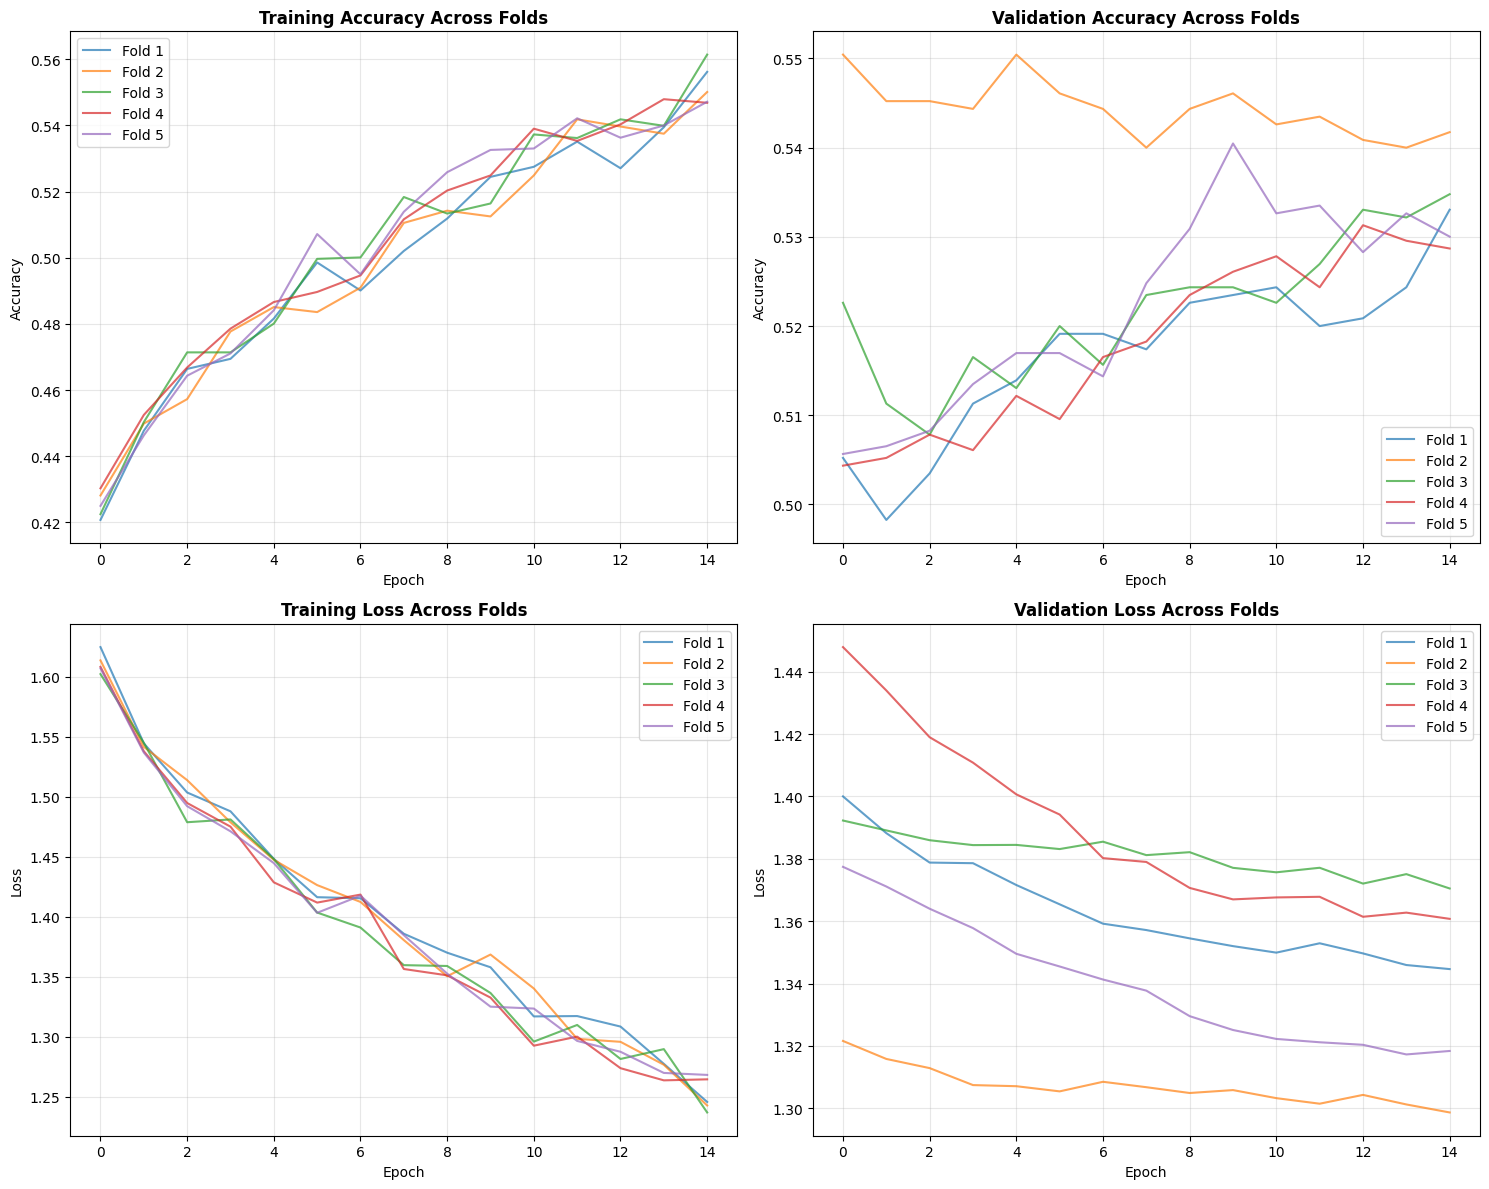

In [9]:
import matplotlib.pyplot as plt


# Plot all folds together
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training Accuracy
axes[0, 0].set_title('Training Accuracy Across Folds', fontsize=12, fontweight='bold')
for i, history in enumerate(fold_histories):
    axes[0, 0].plot(history.history['accuracy'], label=f'Fold {i+1}', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Accuracy
axes[0, 1].set_title('Validation Accuracy Across Folds', fontsize=12, fontweight='bold')
for i, history in enumerate(fold_histories):
    axes[0, 1].plot(history.history['val_accuracy'], label=f'Fold {i+1}', alpha=0.7)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training Loss
axes[1, 0].set_title('Training Loss Across Folds', fontsize=12, fontweight='bold')
for i, history in enumerate(fold_histories):
    axes[1, 0].plot(history.history['loss'], label=f'Fold {i+1}', alpha=0.7)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Validation Loss
axes[1, 1].set_title('Validation Loss Across Folds', fontsize=12, fontweight='bold')
for i, history in enumerate(fold_histories):
    axes[1, 1].plot(history.history['val_loss'], label=f'Fold {i+1}', alpha=0.7)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

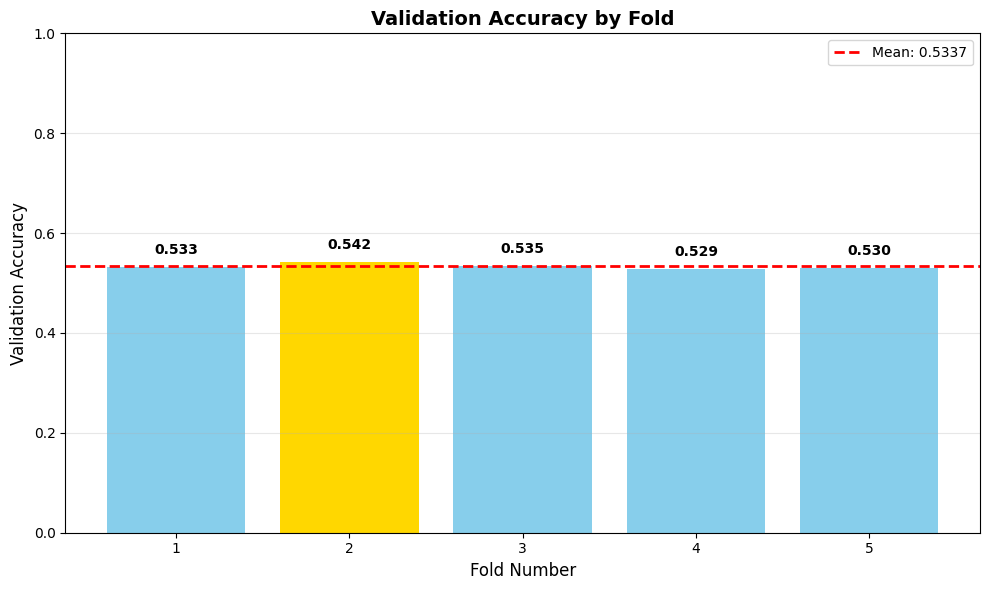

In [10]:
# Bar chart comparing fold accuracies
fold_numbers = [score['fold'] for score in fold_scores]
fold_accs = [score['val_accuracy'] for score in fold_scores]

plt.figure(figsize=(10, 6))
bars = plt.bar(fold_numbers, fold_accs, color=['gold' if i == best_fold-1 else 'skyblue' for i in range(N_SPLITS)])
plt.axhline(y=np.mean(fold_accs), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(fold_accs):.4f}')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Validation Accuracy by Fold', fontsize=14, fontweight='bold')
plt.xticks(fold_numbers)
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (fold, acc) in enumerate(zip(fold_numbers, fold_accs)):
    plt.text(fold, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()